# Exercise 10 - Classification with ANN

The goal of this exercise is to predict whether a customer defaults on his /her credit card.
The data is taken from https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients

The output variable is a binary variable for default payment (Yes = 1, No = 0)

The input variables are the following:

1. Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.
2. Gender (1 = male; 2 = female).
3. Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).
4. Marital status (1 = married; 2 = single; 3 = others).
5. Age (year).
6. the repayment status in September, 2005
7. the repayment status in August, 2005
8. the repayment status in July, 2005
9. the repayment status in June, 2005
10. the repayment status in May, 2005
11. the repayment status in April, 2005
12. amount of bill statement in September, 2005
13. amount of bill statement in August, 2005
14. amount of bill statement in July, 2005
15. amount of bill statement in June, 2005
16. amount of bill statement in May, 2005
17. amount of bill statement in April, 2005
18. amount paid in September, 2005
19. amount paid in August, 2005
20. amount paid in July, 2005
21. amount paid in June, 2005
22. amount paid in May, 2005
23. amount paid in April, 2005.

The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.

**Note:** If you apply a linear model for classification, you may need to transform *gender*, *education*, *marital status*, and *repayment status* into dummy variables.
If you use a ANN, this may not be necessary. However, you may investigate whether the performance is different if categorical variables are described by dummy variables. 


In [32]:
import pandas as pd

# Load the data
df = pd.read_csv("Exercise_10_Data.csv", delimiter=';')


In [33]:
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [34]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   3

In [35]:
df.Default.value_counts()/len(df.Default)

Default
0    0.7788
1    0.2212
Name: count, dtype: float64

In [36]:
# For selecting variable you look at the correlations
df.corr()['Default']

ID          -0.013952
LIMIT_BAL   -0.153520
SEX         -0.039961
EDUCATION    0.028006
MARRIAGE    -0.024339
AGE          0.013890
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
BILL_AMT1   -0.019644
BILL_AMT2   -0.014193
BILL_AMT3   -0.014076
BILL_AMT4   -0.010156
BILL_AMT5   -0.006760
BILL_AMT6   -0.005372
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT3    -0.056250
PAY_AMT4    -0.056827
PAY_AMT5    -0.055124
PAY_AMT6    -0.053183
Default      1.000000
Name: Default, dtype: float64

### Define X and y and split into train and test

In [37]:
# Let us select some (arbituary) variables
X = df[['MARRIAGE', 'AGE', 'PAY_0', 'PAY_2']]
y = df['Default']

In [38]:
# Split the data
from sklearn.model_selection import train_test_split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, shuffle = True)

In [40]:
y_train = pd.DataFrame(y_train)
y_test = pd.DataFrame(y_test)

## ANN model

In [41]:
n_features = X.shape[1]
n_classes = len(y.unique())

In [42]:
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping

In [48]:
model = Sequential()
model.add(Dense(10, input_dim = n_features, activation = 'relu'))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

Output layer activation function artificial neural networks, two uses:
- Prediction
    - Prediction which are -1 < x < 1. **Use tanh**.
    - -inf < x < inf. **Use linear**.
- Classification
    - 2 classes: binary. **Use sigmoid**.
    - Many. **Use softmax**.


In [50]:
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_18 (Dense)            (None, 10)                50        
                                                                 
 dense_19 (Dense)            (None, 10)                110       
                                                                 
 dense_20 (Dense)            (None, 1)                 11        
                                                                 
Total params: 171 (684.00 Byte)
Trainable params: 171 (684.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [51]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam')

In [52]:
early_stop = EarlyStopping(monitor = 'loss', patience = 3, verbose = 1)

In [74]:
history = model.fit(X_train, y_train, epochs = 20, batch_size = 100, callbacks = [early_stop])

Epoch 1/20
240/240 [==============================] - 1s 4ms/step - loss: 0.4556
Epoch 2/20
240/240 [==============================] - 1s 5ms/step - loss: 0.4552
Epoch 3/20
240/240 [==============================] - 1s 4ms/step - loss: 0.4563
Epoch 4/20
240/240 [==============================] - 1s 4ms/step - loss: 0.4549
Epoch 5/20
240/240 [==============================] - 1s 5ms/step - loss: 0.4553
Epoch 6/20
240/240 [==============================] - 1s 5ms/step - loss: 0.4544
Epoch 7/20
240/240 [==============================] - 1s 4ms/step - loss: 0.4551
Epoch 8/20
240/240 [==============================] - 1s 4ms/step - loss: 0.4546
Epoch 9/20
240/240 [==============================] - 1s 6ms/step - loss: 0.4561
Epoch 9: early stopping


## History

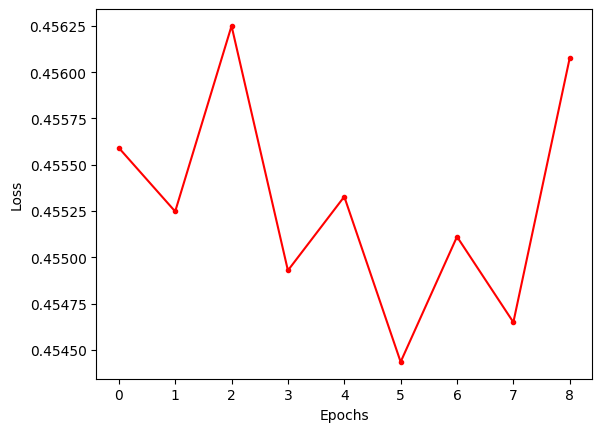

In [75]:
import matplotlib.pyplot as plt

loss_list = history.history['loss']
plt.plot([i for i in range(len(loss_list))], loss_list, color = 'Red', marker = '.')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

### Evaluation and predictions

In [76]:
print(model.evaluate(X_train, y_train, verbose = 1))
print(model.evaluate(X_test, y_test, verbose = 1))

  1/750 [..............................] - ETA: 28s - loss: 0.4623

750/750 [==============================] - 3s 3ms/step - loss: 0.4534
0.45342913269996643
188/188 [==============================] - 1s 3ms/step - loss: 0.4646
0.4645931124687195


In [77]:
y_pred_train = model.predict(X_train).round()
y_pred_test = model.predict(X_test).round()

188/188 [==============================] - 1s 3ms/step


In [69]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from seaborn import heatmap

In [78]:
print('Accuracy on Train is:', accuracy_score(y_train, y_pred_train))
print('Accuracy on Test is:', accuracy_score(y_test, y_pred_test))

Accuracy on Train is: 0.8205
Accuracy on Test is: 0.8165


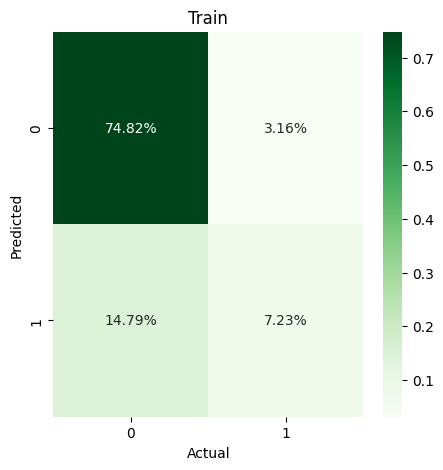

In [79]:
# Heatmap of training set
cm = confusion_matrix(y_train, y_pred_train)

cm_percent = cm / len(y_train)

plt.figure(figsize = (5, 5))
heatmap(cm_percent, annot = True, fmt = '.2%', cmap = 'Greens')

plt.title('Train')
plt.ylabel('Predicted')
plt.xlabel('Actual')
plt.show()

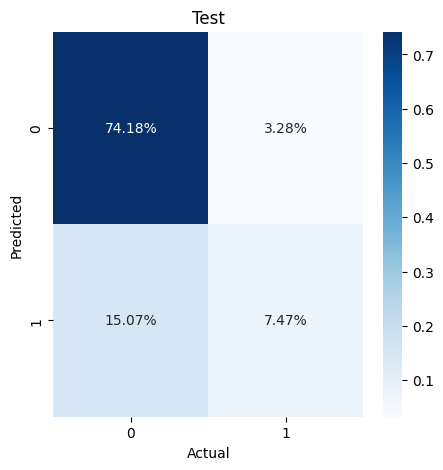

In [80]:
# Heatmap of test set
cm = confusion_matrix(y_test, y_pred_test)

cm_percent = cm / len(y_test)

plt.figure(figsize = (5, 5))
heatmap(cm_percent, annot = True, fmt = '.2%', cmap = 'Blues')

plt.title('Test')
plt.ylabel('Predicted')
plt.xlabel('Actual')
plt.show()